# Named Entity Recognition (NER) and POS Tagging with spaCy

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement NER using spaCy
- Perform POS tagging using spaCy
- Extract named entities from text
- Analyze and visualize NER results

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 03 "Hidden Markov Models and Viterbi" — tagging every token of a sentence is the same sequence-labelling problem, here solved by a modern statistical tagger; and Course 01 (AIAT 111) — Unit 2, lesson 03, which showed where extracted entities end up: as triples in a knowledge graph.

**Used later in:** Course 07 — Unit 4, where the same tokens are handed to pretrained transformer models instead.

---

This notebook covers practical activities from **Course 07, Unit 3**:
- Implementing NER and POS tagging using spaCy

---

## Introduction

**Named Entity Recognition (NER)** identifies and classifies named entities (persons, organizations, locations, etc.) in text. **POS Tagging** assigns part-of-speech tags (noun, verb, adjective, etc.) to words.


## 🌍 Why this matters: 11.5 million documents and a prime minister's resignation

On 3 April 2016 the ICIJ published the **Panama Papers** — a leak of **more than 11.5 million** financial
and legal records from a single offshore law firm. No newsroom can read 11.5 million documents. ICIJ's data
team built an open-source pipeline called **Extract** (Apache Tika to pull text out of files, Tesseract to
OCR the scans, Apache Solr to index the result), then linked the people, companies and addresses appearing
in that text into a graph they explored with **Neo4j** and **Linkurious**: a journalist typed a name and
saw what it connected to. The reporting implicated 140 politicians and public officials across the world,
and Iceland's prime minister resigned within days of publication
(<https://www.icij.org/investigations/panama-papers/>).

The step that turns a wall of text into "this string is a PERSON, that one is an ORG, this one is a DATE"
is exactly what you are about to run. Entity extraction is the difference between a searchable pile and a
queryable database.

**What goes wrong without this lesson.** Keyword search finds *documents*; it does not find *facts*. Search
"Apple" in a news archive and you get every article containing the word — the fruit, the company, a street
name. NER returns typed, linkable records instead: `Tim Cook → PERSON`, `Apple Inc. → ORG`, `1976 → DATE`.
Everything downstream depends on that: knowledge graphs (Course 01, Unit 2), résumé parsing, contract
review, anti-money-laundering screening.

**The same pattern elsewhere:** pharmacovigilance systems pulling drug and adverse-event mentions out of
clinical notes; compliance teams extracting counterparty names from contracts; a Saudi bank screening wire
transfers against a sanctions list. Same task, different label set.

## 📥 Inputs & 📤 Outputs

**Inputs:** two short sample texts defined in the code cells (a tech-companies paragraph for NER, one sentence for POS tagging) and spaCy's small English model `en_core_web_sm`.

**Outputs:** the extracted entities with their types (12 in this run) drawn as highlighted spans over the original paragraph, a token-by-token POS table, and a bar chart comparing what the model finds in the same paragraph as written, lowercased and in capitals — all computed live by spaCy.

---

In [1]:
# Setup: import the analysis stack and load spaCy's small English pipeline.
# The try/except guards let the notebook explain itself (rather than crash)
# if spaCy or its downloaded model is missing on a student machine.

import numpy as np
import pandas as pd
from collections import Counter

# Try importing spaCy
try:
    import spacy
    HAS_SPACY = True
    try:
        nlp = spacy.load("en_core_web_sm")
        print("✅ spaCy English model loaded!")
    except OSError:
        print("⚠️  spaCy model not found. Download with: python -m spacy download en_core_web_sm")
        print("   Using basic spaCy without model...")
        nlp = None
except ImportError:
    HAS_SPACY = False
    nlp = None
    print("⚠️  spaCy not available. Install with: pip install spacy")

print("\n✅ Libraries imported!")

✅ spaCy English model loaded!

✅ Libraries imported!


## Part 1: Named Entity Recognition (NER) with spaCy


In [2]:
# Named Entity Recognition: let spaCy find the people, companies, places, and dates.
# NER turns free text into structured facts — the first step of information-
# extraction pipelines (news mining, resume parsing, knowledge graphs).

if HAS_SPACY and nlp is not None:
    # Sample text for NER
    text = """
    Apple Inc. is an American multinational technology company headquartered in 
    Cupertino, California. Tim Cook is the CEO of Apple. The company was founded 
    by Steve Jobs in 1976. Microsoft Corporation, founded by Bill Gates, is 
    another major technology company based in Redmond, Washington.
    """
    
    print("=" * 60)
    print("Named Entity Recognition (NER)")
    print("=" * 60)
    print(f"\nInput text:\n{text.strip()}\n")
    
    # Process text with spaCy
    doc = nlp(text)
    
    # Extract named entities
    print("Named Entities Found:")
    print("-" * 60)
    entities = []
    for ent in doc.ents:
        entities.append({
            'Text': ent.text, 'Label': ent.label_,
            'Description': spacy.explain(ent.label_)
        })
        print(f"{ent.text:20s} | {ent.label_:15s} | {spacy.explain(ent.label_)}")
    
    print(f"\nTotal entities found: {len(entities)}")
    
    # Count by entity type
    entity_counts = Counter([ent['Label'] for ent in entities])
    print("\nEntity type distribution:")
    for label, count in entity_counts.items():
        print(f"  {label}: {count}")
else:
    print("=" * 60)
    print("NER with spaCy (Installation Required)")
    print("=" * 60)
    print("""
    To use spaCy for NER:
    
    1. Install spaCy:
       pip install spacy
    
    2. Download English model:
       python -m spacy download en_core_web_sm
    
    3. Use spaCy:
       import spacy
       nlp = spacy.load("en_core_web_sm")
       doc = nlp(text)
       for ent in doc.ents:
           print(ent.text, ent.label_)
    """)

Named Entity Recognition (NER)

Input text:
Apple Inc. is an American multinational technology company headquartered in 
    Cupertino, California. Tim Cook is the CEO of Apple. The company was founded 
    by Steve Jobs in 1976. Microsoft Corporation, founded by Bill Gates, is 
    another major technology company based in Redmond, Washington.

Named Entities Found:
------------------------------------------------------------
Apple Inc.           | ORG             | Companies, agencies, institutions, etc.
American             | NORP            | Nationalities or religious or political groups
Cupertino            | GPE             | Countries, cities, states
California           | GPE             | Countries, cities, states
Tim Cook             | PERSON          | People, including fictional
Apple                | ORG             | Companies, agencies, institutions, etc.
Steve Jobs           | PERSON          | People, including fictional
1976                 | DATE            | Absolu

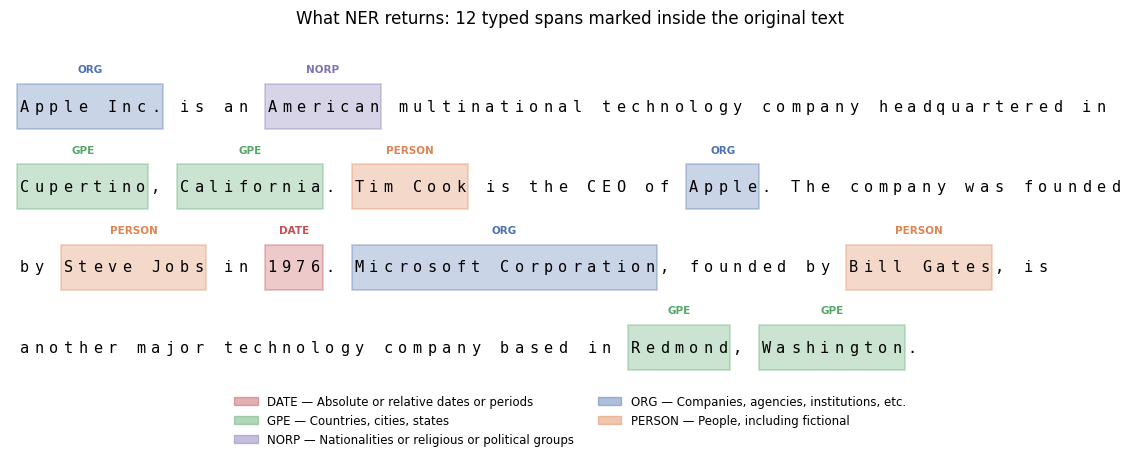

Spans drawn: 12 — identical to the table above: True
Untouched words (everything outside a box) are what the model decided are NOT entities.


In [3]:
# SEE the entities where they live: NER returns SPANS of the original text, not a
# word list. WHY a picture: the printed table above loses the context, and context
# is the whole product — a journalist needs to jump back to the sentence.

if HAS_SPACY and nlp is not None:
    import textwrap
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle, Patch

    # Same paragraph, whitespace normalised so it can be laid out in even lines.
    clean = " ".join(text.split())
    doc_clean = nlp(clean)

    COLORS = {"ORG": "#4C72B0", "PERSON": "#DD8452", "GPE": "#55A868",
              "DATE": "#C44E52", "NORP": "#8172B3"}
    WRAP = 76
    # Wrap into lines and remember where each line starts, so entity character
    # offsets can be turned into (row, column) positions on the picture.
    lines, cursor = [], 0
    for line in textwrap.wrap(clean, WRAP):
        start = clean.index(line, cursor)
        lines.append((start, line))
        cursor = start + len(line)

    fig, ax = plt.subplots(figsize=(11.5, 0.78 * len(lines) + 1.6))
    ax.set_xlim(-0.5, WRAP + 0.5)
    ax.set_ylim(-0.35, len(lines))
    ax.invert_yaxis()
    ax.axis("off")
    # One character per column: a fixed grid makes the highlight boxes line up exactly.
    for row, (offset, line) in enumerate(lines):
        for col, ch in enumerate(line):
            ax.text(col + 0.5, row + 0.58, ch, family="monospace", fontsize=11,
                    ha="center", va="center", zorder=3)

    used = set()
    for ent in doc_clean.ents:
        for row, (offset, line) in enumerate(lines):
            s, e = ent.start_char - offset, ent.end_char - offset
            if 0 <= s and e <= len(line):
                colour = COLORS.get(ent.label_, "#8C8C8C")
                used.add(ent.label_)
                ax.add_patch(Rectangle((s, row + 0.30), e - s, 0.56, facecolor=colour,
                                       alpha=0.30, edgecolor=colour, lw=1.4, zorder=1))
                ax.text((s + e) / 2, row + 0.12, ent.label_, fontsize=7.5, color=colour,
                        ha="center", va="center", fontweight="bold", zorder=4)
                break

    ax.set_title(f"What NER returns: {len(doc_clean.ents)} typed spans marked "
                 f"inside the original text", fontsize=12)
    ax.legend(handles=[Patch(facecolor=COLORS[l], alpha=.45, edgecolor=COLORS[l],
                             label=f"{l} — {spacy.explain(l)}") for l in sorted(used)],
              loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=2,
              fontsize=8.5, frameon=False)
    plt.tight_layout()
    plt.show()

    # The picture and the table above must agree — check, do not assume.
    same = [(e.text, e.label_) for e in doc_clean.ents] == [(e["Text"], e["Label"]) for e in entities]
    print(f"Spans drawn: {len(doc_clean.ents)} — identical to the table above: {same}")
    print("Untouched words (everything outside a box) are what the model decided are NOT entities.")
else:
    print("Note: install spaCy and download en_core_web_sm to draw the entity spans")

**Read the picture.** Every coloured box is one span the model returned; the small word above each box is
the type it assigned; everything left plain — *is, an, multinational, technology, company, headquartered* —
is what the model decided is **not** an entity.

Two things to take from it:

- **NER marks positions in the text, not a bag of keywords.** Each box has a start and an end character,
  which is why an extracted fact can always be traced back to the sentence it came from. That traceability
  is exactly what the ICIJ journalists needed: not "this document mentions a company" but "this company, at
  this spot, in this document".
- **`Apple Inc.` on the first line and `Apple` on the second are two separate `ORG` boxes.** The model
  labels spans; it never decides that two spans are the same real-world company. Keep that in view for the
  first Discuss question below.

*(spaCy also ships `displacy.render(doc, style="ent")`, an interactive HTML version of this same view — worth
knowing, but the figure above is the one that survives being exported to a PDF or a slide.)*

## Part 2: Part-of-Speech (POS) Tagging with spaCy


In [4]:
# Part-of-speech tagging: label every token with its grammatical role.
# POS tags feed downstream tools (lemmatizers, parsers, NER itself) and reveal
# HOW a sentence is built, not just which words it contains.

if HAS_SPACY and nlp is not None:
    # Sample sentence for POS tagging
    sentence = "Natural language processing helps computers understand human language."
    
    print("=" * 60)
    print("Part-of-Speech (POS) Tagging")
    print("=" * 60)
    print(f"\nInput sentence: {sentence}\n")
    
    # Process sentence
    doc = nlp(sentence)
    
    # Extract POS tags
    print("POS Tags:")
    print("-" * 60)
    pos_data = []
    for token in doc:
        pos_data.append({
            'Word': token.text, 'POS': token.pos_,
            'POS_Description': spacy.explain(token.pos_),
            'Tag': token.tag_,
            'Tag_Description': spacy.explain(token.tag_)
        })
        print(f"{token.text:15s} | {token.pos_:10s} | {token.tag_:10s} | {spacy.explain(token.pos_)}")
    
    # Count POS tags
    pos_counts = Counter([token.pos_ for token in doc])
    print("\nPOS distribution:")
    for pos, count in pos_counts.items():
        print(f"  {pos}: {count}")
else:
    print("Note: Install spaCy and download model for POS tagging")

Part-of-Speech (POS) Tagging

Input sentence: Natural language processing helps computers understand human language.

POS Tags:
------------------------------------------------------------
Natural         | ADJ        | JJ         | adjective
language        | NOUN       | NN         | noun
processing      | NOUN       | NN         | noun
helps           | VERB       | VBZ        | verb
computers       | NOUN       | NNS        | noun
understand      | VERB       | VB         | verb
human           | ADJ        | JJ         | adjective
language        | NOUN       | NN         | noun
.               | PUNCT      | .          | punctuation

POS distribution:
  ADJ: 2
  NOUN: 4
  VERB: 2
  PUNCT: 1


## Part 3: Analyzing and Stress-Testing the NER Results

A quick analysis pass over the entities extracted in Part 1: how many entities of each type did the
model find? Bar-charting the distribution is a standard first look at NER output on a new corpus.

Then a stress test in the same figure. `en_core_web_sm` was trained on English news text, where names
are capitalised — so how much of its answer is really coming from capitalisation? The cell re-runs the
**same paragraph** lowercased and in capitals, and plots the three results side by side.


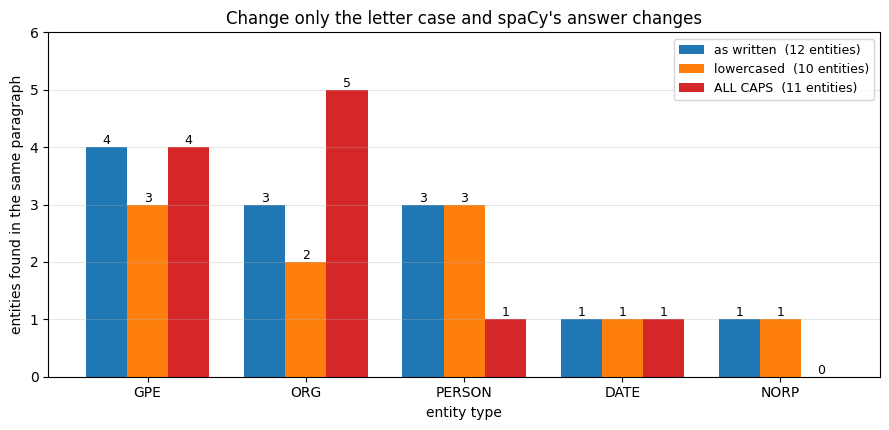

Analysis of the text as written (computed from the extraction above):
  - 12 entities across 5 types
  - most frequent type: GPE (Countries, cities, states) with 4 mentions
  - GPE: ['Cupertino', 'California', 'Redmond', 'Washington']
  - ORG: ['Apple Inc.', 'Apple', 'Microsoft Corporation']
  - PERSON: ['Tim Cook', 'Steve Jobs', 'Bill Gates']
  - NORP: ['American']
  - DATE: ['1976']

lowercased: 10 entities (was 12)
  lost:     ['apple', 'redmond']
  invented: []

ALL CAPS: 11 entities (was 12)
  lost:     ['american', 'steve jobs', 'bill gates']
  invented: [('an american multinational technology company headquartered', 'ORG'), ('founded', 'ORG')]


In [5]:
# Visualize what spaCy found — and then test how fragile that answer is.
# WHY both: the bar chart shows what KIND of information the text carries, and
# re-running the SAME sentences with only the letter case changed shows how much
# of that answer rests on capitalisation — a cue this tagger leans on heavily.

if HAS_SPACY and nlp is not None:
    import matplotlib.pyplot as plt

    # Three versions of ONE paragraph. Nothing but the letter case differs.
    clean = " ".join(text.split())
    variants = {"as written": clean, "lowercased": clean.lower(), "ALL CAPS": clean.upper()}
    found = {name: [(e.text, e.label_) for e in nlp(t).ents] for name, t in variants.items()}
    counts = {name: Counter(lbl for _, lbl in ents) for name, ents in found.items()}

    # Order the entity types by how common they are in the untouched text.
    types = sorted(counts["as written"], key=lambda l: (-counts["as written"][l], l))
    x = np.arange(len(types))
    width = 0.26

    fig, ax = plt.subplots(figsize=(9.0, 4.4))
    for i, (name, colour) in enumerate(zip(variants, ["tab:blue", "tab:orange", "tab:red"])):
        bars = ax.bar(x + (i - 1) * width, [counts[name].get(t, 0) for t in types], width,
                      label=f"{name}  ({sum(counts[name].values())} entities)", color=colour)
        ax.bar_label(bars, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(types)
    ax.set_yticks(range(0, max(max(cnt.values()) for cnt in counts.values()) + 2))
    ax.set_xlabel("entity type")
    ax.set_ylabel("entities found in the same paragraph")
    ax.set_title("Change only the letter case and spaCy's answer changes")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=.3)
    plt.tight_layout()
    plt.show()

    # Compute the headline numbers from the actual extraction (nothing hard-coded).
    label_counts = Counter(ent["Label"] for ent in entities)
    labels_sorted = sorted(label_counts, key=label_counts.get, reverse=True)
    most_common_label, most_common_n = label_counts.most_common(1)[0]
    print("Analysis of the text as written (computed from the extraction above):")
    print(f"  - {len(entities)} entities across {len(label_counts)} types")
    print(f"  - most frequent type: {most_common_label} "
          f"({spacy.explain(most_common_label)}) with {most_common_n} mentions")
    per_type = {}
    for ent in entities:
        per_type.setdefault(ent["Label"], []).append(ent["Text"])
    for label in labels_sorted:
        print(f"  - {label}: {per_type[label]}")

    # What each case variant costs, entity by entity.
    # Compare on the lower-cased span text without trailing punctuation, so a span
    # that only lost its full stop does not look like a different entity.
    def key(span, label):
        return (span.lower().strip(" .,"), label)

    baseline = [key(t, l) for t, l in found["as written"]]
    for name in ("lowercased", "ALL CAPS"):
        got = [key(t, l) for t, l in found[name]]
        lost = [b for b in baseline if b not in got]
        invented = [g for g in got if g not in baseline]
        print(f"\n{name}: {len(found[name])} entities "
              f"(was {len(found['as written'])})")
        print(f"  lost:     {[t for t, l in lost]}")
        print(f"  invented: {[(t, l) for t, l in invented]}")
else:
    print("Note: Install spaCy and download en_core_web_sm to run the visualization")

**Read the picture.** One paragraph, one model, three versions that differ **only** in letter case. Blue is
the text as written, orange is the same text lowercased, red is the same text in capitals; each bar is how
many entities of that type came back.

The totals hardly move — 12, 10, 11 — and that is the trap. What moves is the *content*:

- **Lowercased** loses the bare `Apple` mention and `Redmond`. Capitalisation was the only clue that those
  strings were names; take it away and they become ordinary words.
- **ALL CAPS** is worse in a way the total hides. `PERSON` collapses from 3 to 1 — `STEVE JOBS` and
  `BILL GATES` stop being people — while `ORG` climbs from 3 to 5, because the model invented companies out
  of the verb `FOUNDED` and out of a six-word noun phrase. The printout under the figure lists them.

**The model never says "I don't know".** It returns a confident, wrongly typed span, and a pipeline that
trusts it files that span as a fact. Chat messages, OCR output and shouty headlines all arrive with the
casing broken, which is why "⚠️ Where this breaks" (below) is not a theoretical warning — you have just
measured it on the friendliest possible paragraph.

## 💬 Discuss

Read the extraction spaCy actually produced above before you answer any of these.

1. The `ORG` list came back as `['Apple Inc.', 'Apple', 'Microsoft Corporation']` — the same company
   counted twice. In a Panama-Papers-style investigation, which is the more dangerous error: over-merging
   (deciding `Apple` and `Apple Inc.` are one entity) or under-merging (leaving them apart)? Argue both
   sides, then commit to one and say what evidence would change your mind.
2. `American` was tagged `NORP` — nationality, religious or political group. If this pipeline screened job
   applications or public comments, what could go wrong with a system that reliably extracts a person's
   nationality? Who inside an organization should be allowed to run that query, and who should not?
3. This model was trained on English news text. **Predict before you test:** what will it do with
   *"شركة أرامكو السعودية"*, with the transliterated name *"Abdullah Al-Qahtani"*, and with a Riyadh
   street address? What would you need in order to turn that prediction into a measurement?

## Summary

### Key Concepts:
1. **Named Entity Recognition (NER)**: Identifies and classifies entities
   - Common types: PERSON, ORGANIZATION, GPE (location), DATE, MONEY, etc.
   - Useful for information extraction, question answering, knowledge graphs

2. **Part-of-Speech (POS) Tagging**: Assigns grammatical tags to words
   - Common tags: NOUN, VERB, ADJ, ADV, PRON, DET, etc.
   - Useful for parsing, text understanding, feature engineering

3. **spaCy**: Modern NLP library with pre-trained models
   - Fast and efficient
   - Built-in NER and POS tagging
   - Supports multiple languages

### What you did in this notebook
- Extracted named entities from a sample text with the real `en_core_web_sm` model (Part 1)
- POS-tagged a sentence and counted tag frequencies (Part 2)
- Drew the entities as highlighted spans over the original text (Part 1)
- Analyzed the entity-type distribution and measured how much of it survives a change of letter case (Part 3)

### Applications:
- **NER**: Information extraction, knowledge graph construction, search
- **POS Tagging**: Text preprocessing, feature engineering, parsing

**Reference:** Course 07, Unit 3: "Machine Learning for NLP" - NER and POS tagging practical content


## ⚠️ Where this breaks

**Visible in this notebook's own output:** `Apple Inc.` and `Apple` came back as two separate `ORG`
entities. NER labels *spans*; it does not decide that two spans are the **same real-world thing**. That
second job — **coreference resolution** and **entity linking** — is a separate model, and skipping it is
how you end up counting one company twice, or one customer as two people.

**The assumption that must hold: your text looks like the model's training text.** `en_core_web_sm` was
trained on English, largely news-style prose. Accuracy falls sharply on:

- **Arabic and other non-English text** — this model does not cover it at all; you need an Arabic pipeline,
  and Arabic NER has its own difficulties (no capitalization cue, clitics attached to names, transliteration
  variants of the same person).
- **Domains with their own naming conventions**: clinical notes, legal contracts, chemical names, Saudi
  compound and tribal personal names, company names that are ordinary words.
- **Informal or damaged text**: lowercase social posts, chat, OCR output with broken casing. Capitalization
  is a feature the tagger leans on heavily — remove it and performance drops hard.

**The trap:** NER never says "I don't know". On out-of-domain text it returns confident, wrong spans, and
your pipeline files them as facts. Always measure on a sample of *your own* text before you believe it, and
label a few hundred sentences yourself if you have to.

**Cheaper alternatives when it does not hold:**
- A closed, known list of entities (your product catalogue, a sanctions list, staff names) → a **gazetteer
  lookup** is faster, exact and auditable. Do not train a model to recognize a list you already have.
- A few high-value fields in a fixed template (invoice number, IBAN, date) → **regex plus a validation
  check** beats NER and cannot invent a span.
- You need entity types spaCy does not ship → **fine-tune** a transformer tagger on a few hundred labelled
  sentences of your own text. Domain-matched data beats a bigger general model almost every time.

## 📚 References

Where these ideas come from — seminal papers first, then a modern survey, then the 2024-2025 zero-shot alternatives:

1. Lafferty, J., McCallum, A., & Pereira, F. (2001). *Conditional Random Fields: Probabilistic Models for Segmenting and Labeling Sequence Data*. ICML 2001.
2. Lample, G., Ballesteros, M., Subramanian, S., Kawakami, K., & Dyer, C. (2016). *Neural Architectures for Named Entity Recognition*. NAACL 2016. [arXiv:1603.01360](https://arxiv.org/abs/1603.01360)
3. Li, J., Sun, A., Han, J., & Li, C. (2020). *A Survey on Deep Learning for Named Entity Recognition*. IEEE Transactions on Knowledge and Data Engineering. [arXiv:1812.09449](https://arxiv.org/abs/1812.09449)
4. Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft) — chapter on sequence labeling for part-of-speech and named entities. <https://web.stanford.edu/~jurafsky/slp3/>
5. Stepanov, I., & Shtopko, M. (2024). *GLiNER multi-task: Generalist Lightweight Model for Various Information Extraction Tasks*. [arXiv:2406.12925](https://arxiv.org/abs/2406.12925) — a compact encoder that recognises entity types you name at inference time, instead of the fixed label set spaCy was trained on.
6. Yang, A., Li, A., Yang, B., Zhang, B., Hui, B., et al. (2025). *Qwen3 Technical Report*. [arXiv:2505.09388](https://arxiv.org/abs/2505.09388) — the generative alternative: extraction by prompt, across 119 stated languages including Arabic.
